In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
movies = pd.read_csv("data/movies.csv")
ratings = pd.read_csv("data/ratings.csv")

In [3]:
movies.head()
ratings.head()

movies.info()
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  27278 non-null  int64 
 1   title    27278 non-null  object
 2   genres   27278 non-null  object
dtypes: int64(1), object(2)
memory usage: 639.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 610.4 MB


In [4]:
df = pd.merge(ratings, movies, on="movieId")

In [5]:
movie_stats = df.groupby('title').agg({
    'rating': ['mean', 'count']
})

movie_stats.columns = ['avg_rating', 'rating_count']
movie_stats = movie_stats.sort_values(by='avg_rating', ascending=False)

movie_stats.head()

,avg_rating,rating_count
title,,
"Sierra, La (2005)",5.0,1
A Night for Dying Tigers (2010),5.0,1
Hollywood and The Pentagon: A Dangerous Liaison (2003),5.0,1
When I Walk (2013),5.0,1
A Gun for Jennifer (1997),5.0,1


In [6]:
top_movies = movie_stats[movie_stats['rating_count'] > 100]
top_movies.head(10)

,avg_rating,rating_count
title,,
"Shawshank Redemption, The (1994)",4.446990,63366
"Godfather, The (1972)",4.364732,41355
"Usual Suspects, The (1995)",4.334372,47006
Schindler's List (1993),4.310175,50054
"Godfather: Part II, The (1974)",4.275641,27398
Seven Samurai (Shichinin no samurai) (1954),4.274180,11611
Rear Window (1954),4.271334,17449
Band of Brothers (2001),4.263182,4305
Casablanca (1942),4.258327,24349


In [7]:
df['genres'] = df['genres'].str.split('|')
df = df.explode('genres')

In [8]:
genre_rating = df.groupby('genres')['rating'].mean().sort_values(ascending=False)

In [9]:
genre_count = df.groupby('genres')['rating'].count().sort_values(ascending=False)

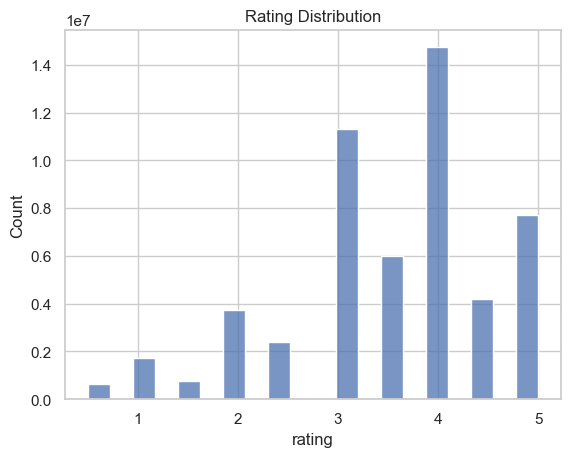

In [10]:
sns.histplot(df['rating'], bins=20)
plt.title("Rating Distribution")
plt.show()

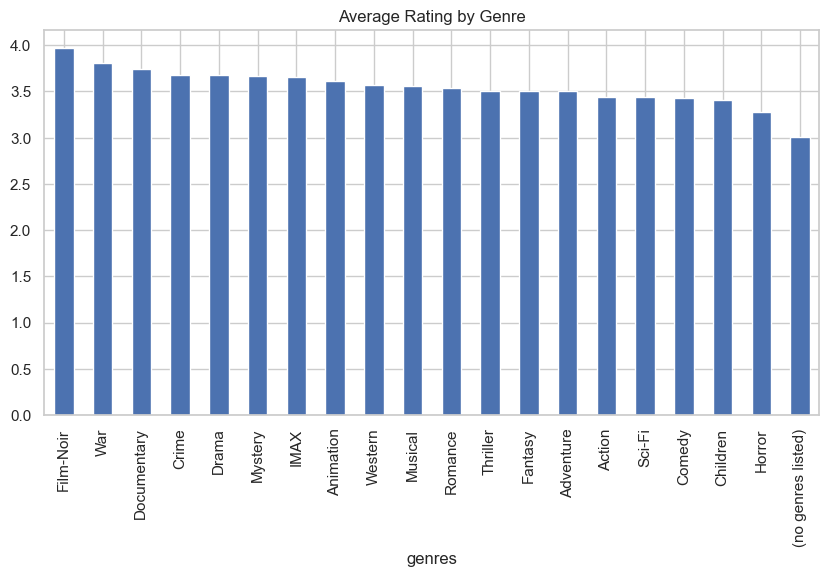

In [11]:
genre_rating.plot(kind='bar', figsize=(10,5))
plt.title("Average Rating by Genre")
plt.show()

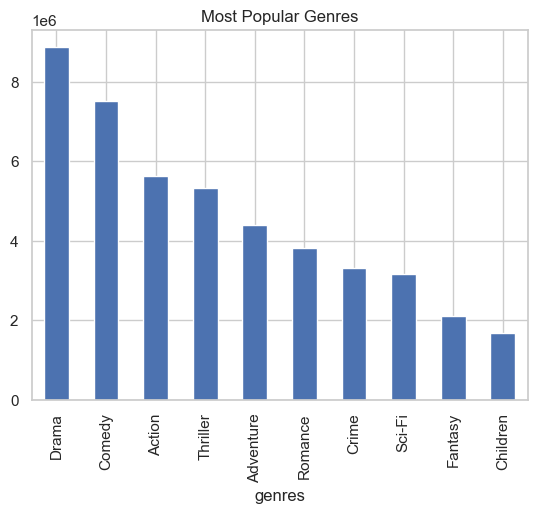

In [12]:
genre_count.head(10).plot(kind='bar')
plt.title("Most Popular Genres")
plt.show()

In [13]:
movie_stats.head()
top_movies.head()
genre_rating.head()
genre_count.head()

genres
Drama        8857853
Comedy       7502234
Action       5614208
Thriller     5313506
Adventure    4380351
Name: rating, dtype: int64

In [14]:
genre_rating = df.groupby('genres')['rating'].mean().sort_values(ascending=False)
genre_rating.head(10)

genres
Film-Noir      3.965381
War            3.809531
Documentary    3.739718
Crime          3.674528
Drama          3.674296
Mystery        3.663509
IMAX           3.655946
Animation      3.617494
Western        3.570498
Musical        3.558091
Name: rating, dtype: float64

In [15]:
genre_rating.head()
top_movies.head()

,avg_rating,rating_count
title,,
"Shawshank Redemption, The (1994)",4.446990,63366
"Godfather, The (1972)",4.364732,41355
"Usual Suspects, The (1995)",4.334372,47006
Schindler's List (1993),4.310175,50054
"Godfather: Part II, The (1974)",4.275641,27398
